# Resume Screening & Candidate Ranking System

## Future Interns - Task 3

### Objective
Build a machine learning system to classify resumes, rank candidates based on job descriptions, and identify skill gaps.

# Import Required Libraries

In [7]:
import pandas as pd

df = pd.read_csv("resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


# Dataset Shape

In [ ]:
print(df.shape)

# Unique Resume Categories

In [ ]:
print(df['Category'].unique())

# Dataset Columns

In [ ]:
print(df.columns)

# Sample Resume Text

In [ ]:
print(df['Resume_str'][0][:1000])

# Resume Text Cleaning and Preprocessing

In [10]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower()

df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

# TF-IDF Feature Extraction

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category']

print(X.shape)

(2484, 10000)


# Job Description Parsing

In [ ]:
job_description = """
Python SQL Machine Learning Data Analysis
"""

print(job_description)

# Resume-to-Role Similarity Scoring

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf.transform([job_description])

similarity_scores = cosine_similarity(job_vector, X)

df['score'] = similarity_scores.flatten()

df[['Category','score']].head()

# Candidate Ranking Based on Similarity Score

In [ ]:
ranked_candidates = df.sort_values(
    by='score',
    ascending=False
)

ranked_candidates[['Category','score']].head(10)

# Skill Gap Analysis

In [ ]:
required_skills = {
    'python',
    'sql',
    'machine',
    'learning',
    'analysis'
}

top_resume = ranked_candidates.iloc[0]['cleaned_resume']

candidate_skills = set(top_resume.split())

missing_skills = required_skills - candidate_skills

print("Required Skills:")
print(required_skills)

print("\nMissing Skills:")
print(missing_skills)

# Visualization of Top Resume Matches

In [ ]:
import matplotlib.pyplot as plt

top10 = ranked_candidates.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['Category'],
    top10['score']
)

plt.xticks(rotation=45)
plt.title("Top Resume Matches")
plt.xlabel("Candidate Category")
plt.ylabel("Similarity Score")

plt.show()

# Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Applying Linear SVM Model

In [15]:
from sklearn.svm import LinearSVC

model = LinearSVC(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


# Model Prediction

In [16]:
predictions = model.predict(X_test)

# Accuracy Evaluation

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7364185110663984


# Classification Report

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.72      0.88      0.79        24
              ADVOCATE       0.59      0.71      0.64        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.62      0.42      0.50        19
                  ARTS       0.60      0.43      0.50        21
            AUTOMOBILE       1.00      0.43      0.60         7
              AVIATION       0.86      0.75      0.80        24
               BANKING       0.82      0.78      0.80        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.70      0.88      0.78        24
                  CHEF       0.86      0.79      0.83        24
          CONSTRUCTION       0.76      0.86      0.81        22
            CONSULTANT       0.77      0.43      0.56        23
              DESIGNER       0.91      0.95      0.93        21
         DIGITAL-MEDIA       0.75      

# Confusion Matrix

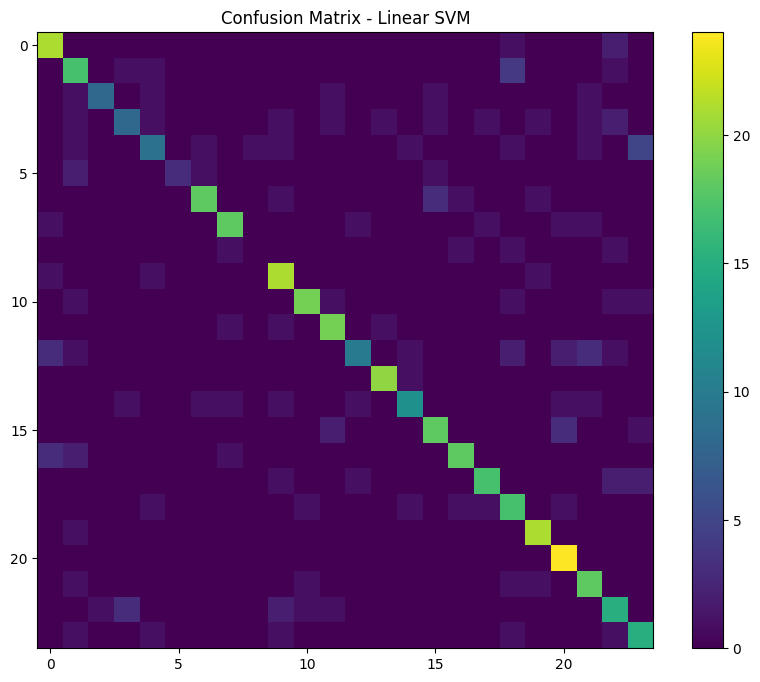

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Confusion Matrix - Linear SVM")
plt.colorbar()
plt.show()